<a href="https://colab.research.google.com/github/yejinPARK48/Analyzing-HR-Data-using-Machine-Learning/blob/main/04_threshold_tuning/phase4_threshold_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4: Threshold Tuning & Evaluation

## Structure
| Section | Description |
|---------|-------------|
| **0. Setup** | Install, import, mount Drive |
| **4-1** | Threshold + min_area sweep |
| **4-2** | BCE/Dice weight tuning (seg-only) |
| **4-3** | Tier-stratified evaluation (Dense / Sparse / Empty) |
| **4-4** | Best config summary & checkpoint selection |


## 0. Setup

In [ ]:
import importlib
if importlib.util.find_spec('segmentation_models_pytorch') is None:
    !pip install segmentation-models-pytorch albumentations -q
if importlib.util.find_spec('cv2') is None:
    !pip install opencv-python-headless scikit-image -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
import random

In [ ]:
import os, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import measure
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Mounted at /content/drive
Device: cuda


## 0-2. Config

In [ ]:
BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
TILE_IMG_DIR  = '/content/fast_tiles/images'   # local SSD (rsync first)
TILE_MASK_DIR = '/content/fast_tiles/masks'
META_DIR      = f'{BASE_DIR}/metadata'
CURATED_DIR   = f'{BASE_DIR}/curated'
CKPT_DIR      = f'{BASE_DIR}/checkpoints'
OUT_DIR       = f'{BASE_DIR}/results_phase4'
os.makedirs(OUT_DIR, exist_ok=True)

SEG_CKPT = f'{CKPT_DIR}/unet_seg_best_full_curated.pt'  # from Phase 3 Part A

# rsync tiles to local SSD
import subprocess
os.makedirs(TILE_IMG_DIR,  exist_ok=True)
os.makedirs(TILE_MASK_DIR, exist_ok=True)
print("Copying tiles to local SSD...")
subprocess.run(['rsync', '-a', '--ignore-existing', f'{BASE_DIR}/tiles/images/',  f'{TILE_IMG_DIR}/'])
subprocess.run(['rsync', '-a', '--ignore-existing', f'{BASE_DIR}/tiles/masks/',   f'{TILE_MASK_DIR}/'])
print("Done!")


Copying tiles to local SSD...
Done!


## 0-3. Load Model & Data

In [ ]:
model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                 in_channels=3, classes=1, activation=None).to(DEVICE)
model.load_state_dict(torch.load(SEG_CKPT, map_location=DEVICE))
model.eval()
print('Seg-only model loaded.')

df_meta = pd.read_csv(f'{META_DIR}/tile_metadata.csv',
                      dtype={'geoid': str, 'tract_id': str})
df_meta['footprint_count']     = df_meta['footprint_count'].fillna(0).astype(float)
df_meta['mask_building_ratio'] = df_meta['mask_building_ratio'].fillna(0).astype(float)

fp_count_map = df_meta.set_index('tile_id')['footprint_count'].to_dict()
ratio_map    = df_meta.set_index('tile_id')['mask_building_ratio'].to_dict()

# ── Load all Pre-Phase 3 QC-passed tiles ─────────────────────────────────
CURATED_DIR  = f'{BASE_DIR}/curated'
stats_csv    = f'{CURATED_DIR}/tile_stats_clean.csv'
all_tile_ids = pd.read_csv(stats_csv)['tile_id'].astype(str).tolist()
print(f'Pre-Phase 3 QC-passed tiles: {len(all_tile_ids)}')

# ── 80/20 random split on all 7,462 tiles (same seed as Phase 3) ────────
random.seed(42)
shuffled = all_tile_ids.copy()
random.shuffle(shuffled)
n         = int(len(shuffled) * 0.8)
train_ids = shuffled[:n]
val_ids   = shuffled[n:]

print(f'Train : {len(train_ids)} | Val : {len(val_ids)}')

val_aug = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class TileDataset(Dataset):
    def __init__(self, tile_ids, img_dir, mask_dir, transform=None):
        self.tile_ids  = tile_ids
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self): return len(self.tile_ids)

    def __getitem__(self, idx):
        tid     = self.tile_ids[idx]
        img     = np.array(Image.open(f'{self.img_dir}/{tid}.png').convert('RGB'))
        mask    = np.array(Image.open(f'{self.mask_dir}/{tid}.png').convert('L'))
        mask    = (mask > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']; mask = torch.tensor(aug['mask']).unsqueeze(0)
        return img, mask, tid

val_ds = TileDataset(val_ids, TILE_IMG_DIR, TILE_MASK_DIR, val_aug)
val_ld = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f'Val loader ready.')

Seg-only model loaded.
Pre-Phase 3 QC-passed tiles: 7462
Train : 5969 | Val : 1493
Val loader ready.


---
## Phase 4-1: Threshold + Min Area Sweep

In [ ]:
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
MIN_AREAS  = [20, 50, 100]

# ── Run inference once, save logits ──────────────────────────────────────
all_logits = []; all_masks = []; all_tids = []
with torch.no_grad():
    for imgs, masks, tids in val_ld:
        logits = model(imgs.to(DEVICE)).cpu()
        all_logits.append(logits)
        all_masks.append(masks)
        all_tids.extend(list(tids))

all_logits = torch.cat(all_logits)   # (N, 1, H, W)
all_masks  = torch.cat(all_masks)    # (N, 1, H, W)
gt_fp      = np.array([float(df_meta.loc[df_meta['tile_id']==t, 'footprint_count'].values[0])
                        if t in df_meta['tile_id'].values else 0.0 for t in all_tids])

print(f'Logits cached: {all_logits.shape}')

# ── Sweep ─────────────────────────────────────────────────────────────────
BATCH = 8  # same as val_ld batch size, to match Phase 3's batch-averaged IoU
n_tiles = len(all_tids)
n_batches = (n_tiles + BATCH - 1) // BATCH

sweep_results = []

for thr, min_area in itertools.product(THRESHOLDS, MIN_AREAS):
    pred_masks = (torch.sigmoid(all_logits) > thr).numpy().astype(bool)  # (N,1,H,W)
    gt_np      = all_masks.numpy().astype(bool)

    # ── IoU: batch-averaged ratio (matches Phase 3's iou_score) ──────────
    batch_ious = []
    for b in range(n_batches):
        s, e = b * BATCH, min((b + 1) * BATCH, n_tiles)
        p = pred_masks[s:e]; g = gt_np[s:e]
        inter = (p & g).sum()
        union = (p | g).sum()
        batch_ious.append(inter / (union + 1e-6))
    mean_iou = np.mean(batch_ious)

    # ── Connected component counts ───────────────────────────────────────
    cc_counts = []
    for i in range(n_tiles):
        p = pred_masks[i, 0]
        labeled = measure.label(p)
        cc_counts.append(sum(1 for r in measure.regionprops(labeled) if r.area >= min_area))

    cc_arr = np.array(cc_counts, dtype=float)
    mae    = np.abs(cc_arr - gt_fp).mean()
    corr   = np.corrcoef(cc_arr, gt_fp)[0, 1] if cc_arr.std() > 0 else 0.0
    sweep_results.append({
        'threshold': thr, 'min_area': min_area,
        'mean_iou': mean_iou, 'mae': mae, 'pearson_r': corr
    })
    print(f'thr={thr} | min_area={min_area:3d} | IoU={mean_iou:.4f} | MAE={mae:.2f} | r={corr:.4f}')

df_sweep = pd.DataFrame(sweep_results)
df_sweep.to_csv(f'{OUT_DIR}/sweep_results.csv', index=False)

best_row = df_sweep.loc[df_sweep['mae'].idxmin()]
print(f'\nBest by MAE: threshold={best_row.threshold} | min_area={int(best_row.min_area)} | MAE={best_row.mae:.2f}')
BEST_THRESHOLD = best_row['threshold']
BEST_MIN_AREA  = int(best_row['min_area'])

Logits cached: torch.Size([1493, 1, 512, 512])
thr=0.3 | min_area= 20 | IoU=0.5987 | MAE=1.63 | r=0.9538
thr=0.3 | min_area= 50 | IoU=0.5987 | MAE=1.61 | r=0.9529
thr=0.3 | min_area=100 | IoU=0.5987 | MAE=1.61 | r=0.9511
thr=0.4 | min_area= 20 | IoU=0.6029 | MAE=1.59 | r=0.9560
thr=0.4 | min_area= 50 | IoU=0.6029 | MAE=1.56 | r=0.9553
thr=0.4 | min_area=100 | IoU=0.6029 | MAE=1.57 | r=0.9537
thr=0.5 | min_area= 20 | IoU=0.6054 | MAE=1.56 | r=0.9580
thr=0.5 | min_area= 50 | IoU=0.6054 | MAE=1.54 | r=0.9568
thr=0.5 | min_area=100 | IoU=0.6054 | MAE=1.54 | r=0.9552
thr=0.6 | min_area= 20 | IoU=0.6070 | MAE=1.54 | r=0.9586
thr=0.6 | min_area= 50 | IoU=0.6070 | MAE=1.52 | r=0.9576
thr=0.6 | min_area=100 | IoU=0.6070 | MAE=1.54 | r=0.9561
thr=0.7 | min_area= 20 | IoU=0.6073 | MAE=1.51 | r=0.9608
thr=0.7 | min_area= 50 | IoU=0.6073 | MAE=1.50 | r=0.9599
thr=0.7 | min_area=100 | IoU=0.6073 | MAE=1.51 | r=0.9586

Best by MAE: threshold=0.7 | min_area=50 | MAE=1.50


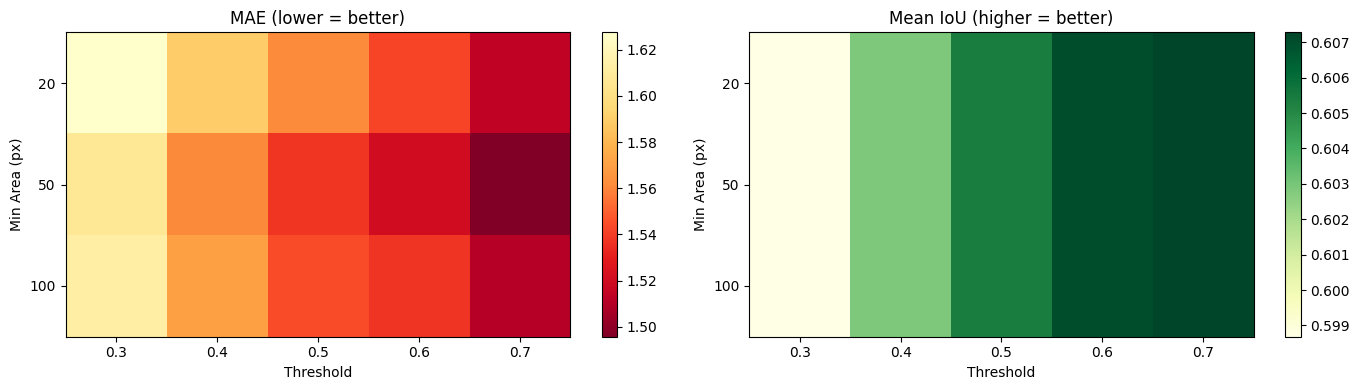

In [ ]:
# ── Heatmap: MAE by threshold x min_area ─────────────────────────────────
pivot = df_sweep.pivot(index='min_area', columns='threshold', values='mae')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im0 = axes[0].imshow(pivot.values, cmap='YlOrRd_r', aspect='auto')
axes[0].set_xticks(range(len(THRESHOLDS))); axes[0].set_xticklabels(THRESHOLDS)
axes[0].set_yticks(range(len(MIN_AREAS)));  axes[0].set_yticklabels(MIN_AREAS)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Min Area (px)')
axes[0].set_title('MAE (lower = better)'); plt.colorbar(im0, ax=axes[0])

pivot_iou = df_sweep.pivot(index='min_area', columns='threshold', values='mean_iou')
im1 = axes[1].imshow(pivot_iou.values, cmap='YlGn', aspect='auto')
axes[1].set_xticks(range(len(THRESHOLDS))); axes[1].set_xticklabels(THRESHOLDS)
axes[1].set_yticks(range(len(MIN_AREAS)));  axes[1].set_yticklabels(MIN_AREAS)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Min Area (px)')
axes[1].set_title('Mean IoU (higher = better)'); plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/sweep_heatmap.png', dpi=150)
plt.show()


---
## Phase 4-2: BCE/Dice Weight Tuning (Seg-Only)

In [ ]:
# ── Try different BCE/Dice ratios on val set ─────────────────────────────
# Uses cached logits from 4-1 — no re-inference needed
WEIGHT_COMBOS = [(0.3, 0.7), (0.5, 0.5), (0.7, 0.3), (1.0, 0.0), (0.0, 1.0)]

def dice_loss_np(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    return 1 - (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)

weight_results = []
gt_np = all_masks.numpy()

for bce_w, dice_w in WEIGHT_COMBOS:
    losses = []
    bce_fn = nn.BCEWithLogitsLoss()
    for i in range(len(all_tids)):
        logit = all_logits[i]
        mask  = all_masks[i]
        bce   = bce_fn(logit, mask).item()
        prob  = torch.sigmoid(logit).numpy()
        dice  = dice_loss_np(prob, gt_np[i])
        losses.append(bce_w * bce + dice_w * dice)
    weight_results.append({'bce_w': bce_w, 'dice_w': dice_w, 'val_loss': np.mean(losses)})
    print(f'BCE={bce_w} Dice={dice_w} | Val Loss={np.mean(losses):.4f}')

df_weights = pd.DataFrame(weight_results)
df_weights.to_csv(f'{OUT_DIR}/weight_tuning_results.csv', index=False)

best_w = df_weights.loc[df_weights['val_loss'].idxmin()]
print(f'\nBest: BCE={best_w.bce_w} | Dice={best_w.dice_w} | Loss={best_w.val_loss:.4f}')
BEST_BCE_W  = best_w['bce_w']
BEST_DICE_W = best_w['dice_w']


BCE=0.3 Dice=0.7 | Val Loss=0.4704
BCE=0.5 Dice=0.5 | Val Loss=0.3453
BCE=0.7 Dice=0.3 | Val Loss=0.2201
BCE=1.0 Dice=0.0 | Val Loss=0.0323
BCE=0.0 Dice=1.0 | Val Loss=0.6582

Best: BCE=1.0 | Dice=0.0 | Loss=0.0323


---
## Phase 4-3: Tier-Stratified Evaluation

> Same model, evaluated separately on Dense / Sparse / Empty tiles
> to show model performs well where buildings actually exist.

In [ ]:
# ── Tier classification ───────────────────────────────────────────────────
def classify_tier(ratio):
    if ratio >= 0.05:    return 'Dense'
    elif ratio >= 0.001: return 'Sparse'
    else:                return 'Empty'

df_val = df_meta[df_meta['tile_id'].isin(all_tids)].copy()
df_val['tier'] = df_val['mask_building_ratio'].apply(classify_tier)
tier_map = dict(zip(df_val['tile_id'].astype(str), df_val['tier']))

print('Tier distribution (val set):')
print(df_val['tier'].value_counts().to_string())

# ── Evaluate per tier using BEST threshold/min_area from 4-1 ─────────────
pred_masks = (torch.sigmoid(all_logits) > BEST_THRESHOLD).numpy()
gt_np      = all_masks.numpy()

tier_rows = []
for tier in ['Dense', 'Sparse', 'Empty']:
    idx = [i for i, t in enumerate(all_tids) if tier_map.get(t) == tier]
    if not idx: continue

    ious = []; cc_counts = []
    for i in idx:
        p = pred_masks[i, 0]; g = gt_np[i, 0]
        inter = (p & g.astype(bool)).sum()
        union = (p | g.astype(bool)).sum()
        ious.append(inter / union if union > 0 else 0.0)

        labeled = measure.label(p)
        cc_counts.append(sum(1 for r in measure.regionprops(labeled) if r.area >= BEST_MIN_AREA))

    gt_sub  = gt_fp[idx]
    cc_arr  = np.array(cc_counts, dtype=float)
    mae     = np.abs(cc_arr - gt_sub).mean()
    corr    = np.corrcoef(cc_arr, gt_sub)[0, 1] if cc_arr.std() > 0 else 0.0
    tier_rows.append({
        'Tier': tier, 'N tiles': len(idx),
        'Mean IoU': round(np.mean(ious), 4),
        'MAE': round(mae, 2),
        'Pearson r': round(corr, 4)
    })

df_tier = pd.DataFrame(tier_rows)
df_tier.to_csv(f'{OUT_DIR}/tier_evaluation.csv', index=False)
print('\n', df_tier.to_string(index=False))


Tier distribution (val set):
tier
Empty     782
Sparse    516
Dense     195

   Tier  N tiles  Mean IoU  MAE  Pearson r
 Dense      195    0.6562 7.41     0.9157
Sparse      516    0.5687 1.45     0.8857
 Empty      782    0.0086 0.05     0.3030


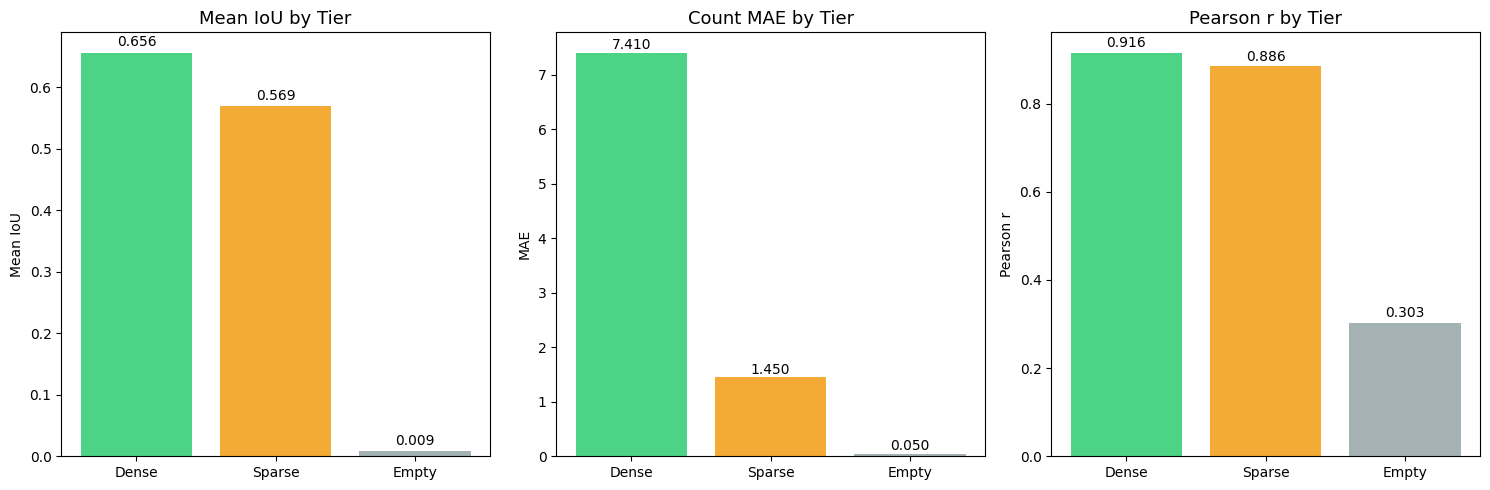

In [ ]:
# ── Tier bar charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2ecc71', '#f39c12', '#95a5a6']  # Dense, Sparse, Empty

for ax, col, title in zip(axes,
    ['Mean IoU', 'MAE', 'Pearson r'],
    ['Mean IoU by Tier', 'Count MAE by Tier', 'Pearson r by Tier']):
    bars = ax.bar(df_tier['Tier'], df_tier[col], color=colors, alpha=0.85)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(col)
    for bar, val in zip(bars, df_tier[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/tier_evaluation.png', dpi=150)
plt.show()


---
## Phase 4-4: Best Config Summary & Checkpoint Selection

In [ ]:
best_iou = df_sweep.loc[(df_sweep['threshold']==BEST_THRESHOLD) &
                        (df_sweep['min_area']==BEST_MIN_AREA), 'mean_iou'].values[0]
best_corr = df_sweep.loc[(df_sweep['threshold']==BEST_THRESHOLD) &
                         (df_sweep['min_area']==BEST_MIN_AREA), 'pearson_r'].values[0]

print('=' * 60)
print('  PHASE 4 — BEST CONFIGURATION SUMMARY')
print('=' * 60)
print(f'  Threshold   : {BEST_THRESHOLD}')
print(f'  Min area    : {BEST_MIN_AREA} px')
print(f'  IoU         : {best_iou:.4f}')
print(f'  MAE         : {best_row.mae:.2f}')
print(f'  Pearson r   : {best_corr:.4f}')
print(f'  Checkpoint  : {SEG_CKPT}')
print('=' * 60)
print()
print('  → Use these values in Phase 5 config (BEST_THRESHOLD, BEST_MIN_AREA, BEST_CKPT)')

# Save summary
summary = {
    'best_threshold': BEST_THRESHOLD,
    'best_min_area':  BEST_MIN_AREA,
    'iou':            best_iou,
    'mae':            best_row.mae,
    'pearson_r':      best_corr,
    'checkpoint':     SEG_CKPT,
}
pd.DataFrame([summary]).to_csv(f'{OUT_DIR}/phase4_best_config.csv', index=False)
print(f'\nSaved: {OUT_DIR}/phase4_best_config.csv')

  PHASE 4 — BEST CONFIGURATION SUMMARY
  Threshold   : 0.7
  Min area    : 50 px
  IoU         : 0.6073
  MAE         : 1.50
  Pearson r   : 0.9599
  Checkpoint  : /content/drive/MyDrive/michigan_unet_project/checkpoints/unet_seg_best_full_curated.pt

  → Use these values in Phase 5 config (BEST_THRESHOLD, BEST_MIN_AREA, BEST_CKPT)

Saved: /content/drive/MyDrive/michigan_unet_project/results_phase4/phase4_best_config.csv
